In [31]:
import os
import pandas as pd

print("Current working directory:")
print(os.getcwd())


Current working directory:
d:\project\dark-pattern-classifier


In [32]:
print("Files in the current folder:")

for file in os.listdir():
    print(file)

Files in the current folder:
.git
.venv
AI-Powered _Dark Pattern_ Text Classifier.ipynb
dark_pattern_model.pkl
patterns.csv
pattern_classifications.csv
tfidf_vectorizer.pkl


In [33]:
import pandas as pd
from pathlib import Path

# Dataset is in the same folder as this notebook
file_path = Path("pattern_classifications.csv")

# Check whether the dataset exists
if not file_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {file_path.resolve()}"
    )

# Load dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (2700, 2)

Columns:
['Pattern String', 'classification']

First 5 rows:


,Pattern String,classification
0,FREE SHIPPING ON ORDERS OVER $100!,0.0
1,SOME EXCLUSIONS APPLY - LEARN MORE,0.0
2,HAVE A QUESTION? - CONTACT US,0.0
3,WELCOME TO 034MOTORSPORT!,0.0
4,SHOP AUDISHOP VOLKSWAGENPERFORMANCE SOFTWARE03...,0.0


In [34]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['classification'].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pattern String  2427 non-null   str    
 1   classification  2699 non-null   float64
dtypes: float64(1), str(1)
memory usage: 42.3 KB
None

Missing values:
Pattern String    273
classification      1
dtype: int64

Class distribution:
classification
0.0    2094
1.0     605
NaN       1
Name: count, dtype: int64


In [35]:
# Remove rows where text or classification is missing
df = df.dropna(subset=['Pattern String', 'classification'])

# Convert text to string
df['Pattern String'] = df['Pattern String'].astype(str)

# Convert classification to integer
df['classification'] = df['classification'].astype(int)

print("Dataset after cleaning:", df.shape)

print(df.head())

Dataset after cleaning: (2426, 2)
                                      Pattern String  classification
0                 FREE SHIPPING ON ORDERS OVER $100!               0
1                 SOME EXCLUSIONS APPLY - LEARN MORE               0
2                      HAVE A QUESTION? - CONTACT US               0
3                          WELCOME TO 034MOTORSPORT!               0
4  SHOP AUDISHOP VOLKSWAGENPERFORMANCE SOFTWARE03...               0


In [36]:
X = df['Pattern String']
y = df['classification']

print("Number of text samples:", len(X))
print("Number of labels:", len(y))

Number of text samples: 2426
Number of labels: 2426


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1940
Testing samples: 486


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1940, 5000)
Testing TF-IDF shape: (486, 5000)


In [39]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [40]:
lr_pred = lr_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(lr_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred, zero_division=0)
recall = recall_score(y_test, lr_pred, zero_division=0)
f1 = f1_score(y_test, lr_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")

print(classification_report(
    y_test,
    lr_pred,
    target_names=["Not Deceptive", "Deceptive"],
    zero_division=0
))

Accuracy : 0.8415637860082305
Precision: 0.6744186046511628
Recall   : 0.5420560747663551
F1 Score : 0.6010362694300518

Classification Report:
               precision    recall  f1-score   support

Not Deceptive       0.88      0.93      0.90       379
    Deceptive       0.67      0.54      0.60       107

     accuracy                           0.84       486
    macro avg       0.78      0.73      0.75       486
 weighted avg       0.83      0.84      0.84       486



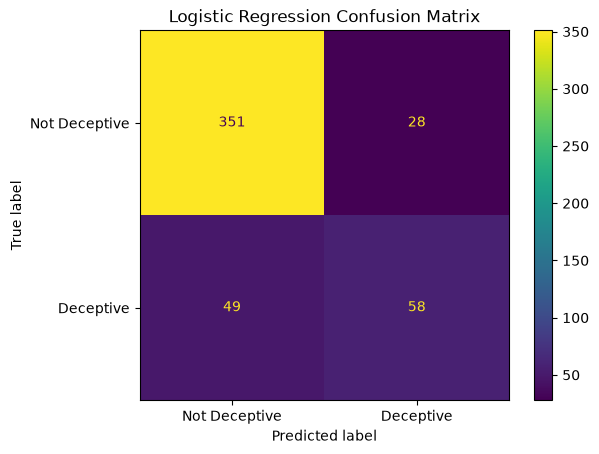

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Deceptive", "Deceptive"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred, zero_division=0)
recall = recall_score(y_test, lr_pred, zero_division=0)
f1 = f1_score(y_test, lr_pred, zero_division=0)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.8416
Precision: 0.6744
Recall   : 0.5421
F1 Score : 0.601


In [44]:
import joblib

joblib.dump(lr_model, "dark_pattern_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [45]:
user_text = input("Enter a pattern: ")

if not user_text.strip():
    print("Please enter some text.")
else:
    # Convert user input to TF-IDF
    text_tfidf = tfidf.transform([user_text])

    # Make prediction
    prediction = lr_model.predict(text_tfidf)[0]

    # Get confidence
    probabilities = lr_model.predict_proba(text_tfidf)[0]
    confidence = max(probabilities) * 100

    # Confidence level
    if confidence >= 80:
        confidence_level = "HIGH"
    elif confidence >= 60:
        confidence_level = "MEDIUM"
    else:
        confidence_level = "LOW"

    # Prediction result
    if prediction == 1:
        result = "DECEPTIVE PATTERN"
    else:
        result = "NOT DECEPTIVE"

    print("\nPrediction:", result)
    print("Confidence:", round(confidence, 2), "%")
    print("Confidence Level:", confidence_level)
    


Prediction: DECEPTIVE PATTERN
Confidence: 68.08 %
Confidence Level: MEDIUM
